SEMINAR 1: Graph Pathfinding with Genetic Algorithms

In [1]:
import random

def generate_graph_file(filename, num_nodes, density=0.3, max_weight=20):
    edges = []
    
    # 1. Create a simple path that connects all of the nodes
    for i in range(1, num_nodes):
        weight = random.randint(1, max_weight)
        edges.append(f"{i} {i+1} {weight}")
    
    # 2. Adding additional edges according to the density
    for i in range(1, num_nodes + 1):
        for j in range(i + 2, num_nodes + 1):  # evitamos duplicados y ciclos triviales
            if random.random() < density:
                weight = random.randint(1, max_weight)
                edges.append(f"{i} {j} {weight}")

    # 3. Save the file            
    with open(filename, 'w') as f:
        f.write(f"{num_nodes}\n")
        for edge in edges:
            f.write(f"{edge}\n")
    print(f"Generated {filename} with {num_nodes} nodes and {len(edges)} edges.")

# Generate examples
generate_graph_file('graph_small.txt', num_nodes=5, density=0.4)
generate_graph_file('graph_medium.txt', num_nodes=10, density=0.3)
generate_graph_file('graph_large.txt', num_nodes=20, density=0.2)
generate_graph_file('graph_huge.txt', num_nodes=50, density=0.1)
generate_graph_file('graph_small_2.txt', num_nodes=5, density=0.4)
generate_graph_file('graph_medium_2.txt', num_nodes=10, density=0.3)
generate_graph_file('graph_large_2.txt', num_nodes=20, density=0.2)
generate_graph_file('graph_huge_2.txt', num_nodes=50, density=0.3)

Generated graph_small.txt with 5 nodes and 6 edges.
Generated graph_medium.txt with 10 nodes and 21 edges.
Generated graph_large.txt with 20 nodes and 55 edges.
Generated graph_huge.txt with 50 nodes and 164 edges.
Generated graph_small_2.txt with 5 nodes and 8 edges.
Generated graph_medium_2.txt with 10 nodes and 25 edges.
Generated graph_large_2.txt with 20 nodes and 54 edges.
Generated graph_huge_2.txt with 50 nodes and 441 edges.


TASK 1:

Graph loaded: 10 nodes
Searching shortest path: 1 -> 5


C:\Users\agran\PycharmProjects\IntSys\.venv\Lib\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


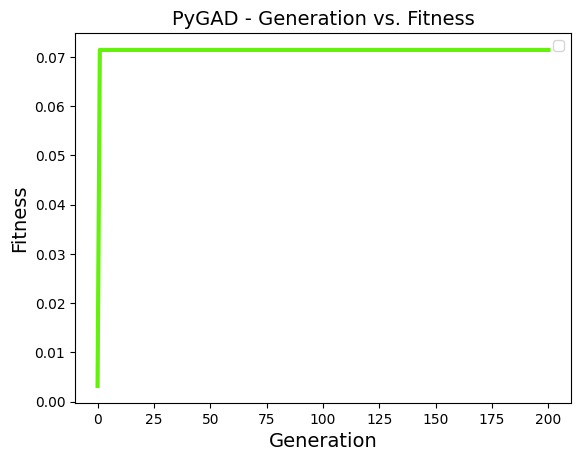

Best fitness: 0.07142857142857142

--- Path Found ---
SUCCESS: [1, 4, 5]
Total distance: 14.0


In [2]:
import numpy as np
import pygad

# Load Data
filename = 'graph_medium_2.txt'

with open(filename, 'r') as f:
    lines = f.readlines()
    num_nodes = int(lines[0].strip())
    adj = np.full((num_nodes + 1, num_nodes + 1), np.inf)

    for line in lines[1:]:
        u, v, w = map(int, line.split())
        adj[u][v] = w

    print(f"Graph loaded: {num_nodes} nodes")


# Setup of the Problem
start_node = 1
end_node = 5
print(f"Searching shortest path: {start_node} -> {end_node}")

# --- 3. FITNESS FUNCTION ---
def fitness_func(ga, solution, idx):
    cost = 0
    penalty = 0
    curr = start_node
    reached = False
    for gene in solution:
        node = int(gene)
        if reached:
            break
        if node == curr:
            continue

        d = adj[curr][node] if (curr <= num_nodes and node <= num_nodes) else np.inf
        
        if d == np.inf:
            penalty += 100  
        else:
            cost += d
            curr = node
            if curr == end_node:
                reached = True

    # Strong penalty if destination not reached
    if not reached:
        penalty += 5000

    total = cost + penalty
    return 99999 if total == 0 else 1.0 / total

# Configuration of the GA
generations = 200
population = 50

ga_instance = pygad.GA(
    num_generations=generations,
    num_parents_mating=int(population * 0.2),
    fitness_func=fitness_func,
    sol_per_pop=population,
    num_genes=num_nodes, 
    gene_space=list(range(1, num_nodes + 1)),
    gene_type=int,
    crossover_type="two_points",
    mutation_type="random",
    mutation_percent_genes=10,
    keep_parents=2
)

ga_instance.run()

# Results
ga_instance.plot_fitness()
solution, fit, _ = ga_instance.best_solution()
print(f"Best fitness: {fit}")

# Decoding path
path = [start_node]
curr = start_node
total_distance = 0

print("\n--- Path Found ---")
for gene in solution:
    node = int(gene)
    if curr == end_node:
        break
    if node == curr:
        continue
    if curr <= num_nodes and node <= num_nodes and adj[curr][node] != np.inf:
        total_distance += adj[curr][node]
        curr = node
        path.append(curr)

print(f"SUCCESS: {path}")
print(f"Total distance: {total_distance}")

Some things to take in mind in Task 1 are that we use a direct code, the cromosome is a list of ints that represent nodes. We also used 1/(cost + penalisations) where the penalisations are vital so the algorithm learns that the non existent edges are bad.

Based on the results of the Task 1, we can see that when we increment the population, it improves the exploration capacity, finding better solutions in less generations. However, it cost more per iteration.

TASK 2:

Graph loaded: 10 nodes
Targets: [1, 5, 10]


C:\Users\agran\PycharmProjects\IntSys\.venv\Lib\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


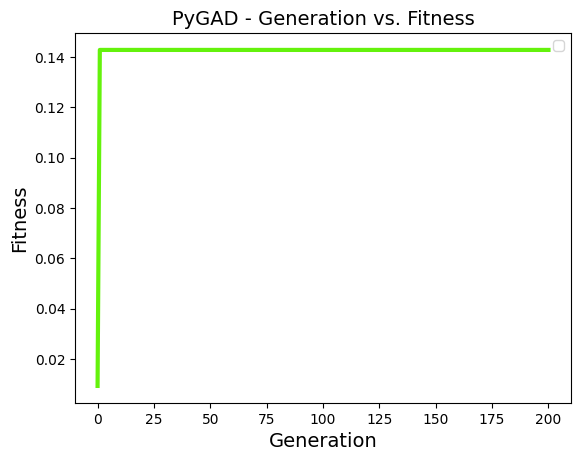

Best fitness: 0.14285714285714285
Path found: [1, 5, 10]
Total distance: 7.0


In [3]:
import numpy as np
import pygad
import matplotlib.pyplot as plt

# Load Data
filename = 'graph_medium.txt'

with open(filename, 'r') as f:
    lines = f.readlines()
    N = int(lines[0].strip())
    adj = np.full((N + 1, N + 1), np.inf)

    for line in lines[1:]:
        u, v, w = map(int, line.split())
        adj[u][v] = w

    print(f"Graph loaded: {N} nodes")

# Problem Setup
targets = [1, 5, 10]
print("Targets:", targets)

# Fitness Function
def fitness_multi_target(ga, solution, idx):
    dist = 0
    penalty = 0
    curr = targets[0]
    target_idx = 1

    for gene in solution:
        node = int(gene)
        if target_idx >= len(targets):
            break
        if node == curr:
            continue

        d = adj[curr][node] if (curr <= N and node <= N) else np.inf

        if d == np.inf:
            penalty += 50  # penalty for invalid move
        else:
            dist += d
            curr = node
            if curr == targets[target_idx]:
                target_idx += 1

    missed = len(targets) - target_idx
    if missed > 0:
        penalty += 2000 * missed

    cost = dist + penalty
    return 99999 if cost == 0 else 1.0 / cost

# Custom Operations
def custom_crossover(parents, offspring_size, ga_instance):
    offspring = []
    for k in range(offspring_size[0]):
        p1 = parents[k % parents.shape[0]]
        p2 = parents[(k+1) % parents.shape[0]]
        cut = np.random.randint(1, len(p1)-1)
        child = np.concatenate((p1[:cut], p2[cut:]))
        # Ensure targets are present in correct order
        for i, t in enumerate(targets):
            child[i] = t
        offspring.append(child)
    return np.array(offspring)

# Custom mutation: randomly change a gene but never remove targets
def custom_mutation(offspring, ga_instance):
    for child in offspring:
        idx = np.random.randint(len(child))
        if child[idx] not in targets: 
            child[idx] = np.random.randint(1, N+1)
    return offspring

# Config of the GA
generations = 200
population = 50
TOTAL_GENES = N * 2

ga_instance = pygad.GA(
    num_generations=generations,
    num_parents_mating=int(population * 0.2),
    fitness_func=fitness_multi_target,
    sol_per_pop=population,
    num_genes=TOTAL_GENES,
    gene_space=list(range(1, N + 1)),
    gene_type=int,
    crossover_type=custom_crossover,
    mutation_type=custom_mutation,
    mutation_percent_genes=20,
    keep_parents=2
)

ga_instance.run()

# Results
ga_instance.plot_fitness()
solution, sol_fit, _ = ga_instance.best_solution()
print("Best fitness:", sol_fit)

# Decoding path
path = [targets[0]]
curr = targets[0]
idx = 1
total_dist = 0

for gene in solution:
    node = int(gene)
    if idx >= len(targets):
        break
    if node == curr:
        continue
    if curr <= N and node <= N and adj[curr][node] != np.inf:
        total_dist += adj[curr][node]
        curr = node
        path.append(curr)
        if curr == targets[idx]:
            idx += 1

print("Path found:", path)
print("Total distance:", total_dist)

Now in Task 2 the problem is sequential, we need to follow a path, so we incremented the cromosome size to N*2 so we give the agent some leewat in case he has to make detours or turn back.

The result tells us that the mutation rate is critical, if it is low the algorithm gets stuck in a dead end. If it is high, it destroys the good solutions. The most stable is a value between 10 and 20%.

TASK 3:

Graph loaded: 50 nodes
Running Genetic Algorithm...


C:\Users\agran\PycharmProjects\IntSys\.venv\Lib\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


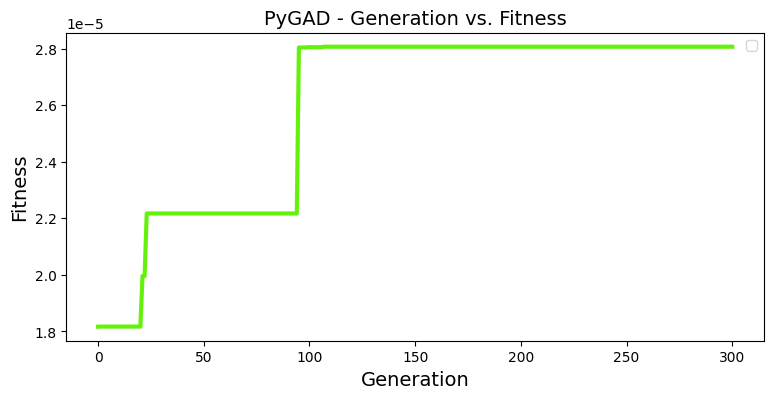

Best Fitness: 2.806544862619629e-05
Approximate cost: 35630.00
Agent 1: [1, 2, 3, 4, 5, 9, 11, 24, 35, 40, 46, 'wait', 'wait', 47, 48, 'wait', 49, 'wait', 'wait', 'wait', 50, 'wait', 'wait', 'wait', 'wait', 'wait', 'wait', 'wait', 'wait', 'wait', 'wait']
Agent 2: [3, 'wait', 8, 45, 'invalid']


In [12]:
import numpy as np
import pygad
import random

# --- 1. LOAD GRAPH ---
filename = 'graph_huge.txt'

with open(filename, 'r') as f:
    lines = f.readlines()
    N = int(lines[0].strip())
    adj = np.full((N + 1, N + 1), np.inf)

    for line in lines[1:]:
        u, v, w = map(int, line.split())
        adj[u][v] = w
            
    print(f"Graph loaded: {N} nodes")

# Problem Setup
STARTS = [1, 3]           # Starting nodes for each agent
TARGETS = [2, 4, 5, 8]    # Sequence of objectives to complete
N_AGENTS = len(STARTS)
MAX_STEPS = 30            # Maximum steps per agent
NUM_GENES = N_AGENTS * MAX_STEPS

# Custom Mutation
def custom_mutation(offspring, ga):
    
    for i in range(offspring.shape[0]):      # each individual
        for j in range(offspring.shape[1]):  # each gene
            if random.random() < 0.2:        # 20% mutation chance
                agent_id = j // MAX_STEPS
                step_id = j % MAX_STEPS
                prev = STARTS[agent_id] if step_id == 0 else offspring[i, j-1]

                # Valid options: stay or move to a neighbor
                options = [prev]
                for node in range(1, N + 1):
                    if node != prev and adj[prev][node] != np.inf:
                        options.append(node)

                offspring[i, j] = random.choice(options)
    return offspring

# Fitness Function
def fitness_function_task3(ga, solution, idx):
    routes = []
    for i in range(N_AGENTS):
        start = i * MAX_STEPS
        routes.append(solution[start:start + MAX_STEPS])

    positions = list(STARTS)
    times = [0] * N_AGENTS
    step_ptr = [0] * N_AGENTS
    target_ptr = [0] * N_AGENTS
    penalties = [0] * N_AGENTS
    finished = [False] * N_AGENTS

    node_free = {n: 0 for n in STARTS}
    edge_free = {}

    total_targets_done = 0
    iterations = 0

    # Simulation loop
    while iterations < (N_AGENTS * MAX_STEPS * 2):
        active = [i for i in range(N_AGENTS) if not finished[i]]
        if not active:
            break

        # Move the agent with the lowest current time
        agent = min(active, key=lambda x: times[x])

        if step_ptr[agent] >= MAX_STEPS:
            finished[agent] = True
            iterations += 1
            continue

        nxt = int(routes[agent][step_ptr[agent]])
        step_ptr[agent] += 1
        curr = positions[agent]

        # CASE A: wait (stay at same node)
        if nxt == curr:
            t_ready = max(times[agent], node_free.get(curr, 0))
            t_end = t_ready + 20
            times[agent] = t_end
            node_free[curr] = t_end

        # CASE B: move
        else:
            if adj[curr][nxt] == np.inf:
                penalties[agent] += 10000
                finished[agent] = True
            else:
                dist = adj[curr][nxt]
                edge_key = tuple(sorted((curr, nxt)))
                t_edge = edge_free.get(edge_key, 0)
                t_dest = node_free.get(nxt, 0)

                t_start = max(times[agent], t_edge, t_dest - dist)
                t_arrive = t_start + dist
                t_finish = t_arrive + 10 

                edge_free[edge_key] = t_arrive
                node_free[nxt] = t_finish

                times[agent] = t_finish
                positions[agent] = nxt

                # Check if target reached
                ti = target_ptr[agent]
                if ti < len(TARGETS) and nxt == TARGETS[ti]:
                    target_ptr[agent] += 1
                    total_targets_done += 1

        iterations += 1

    # Final scoring
    makespan = max(times)
    total_pen = sum(penalties)
    missing = (len(TARGETS) * N_AGENTS) - total_targets_done

    return 1.0 / (makespan + total_pen + (missing * 5000) + 1)

# Run the GA
generations = 300
population = 100

ga = pygad.GA(
    num_generations=generations,
    num_parents_mating=10,
    fitness_func=fitness_function_task3,
    sol_per_pop=population,
    num_genes=NUM_GENES,
    gene_space=list(range(1, N + 1)),
    gene_type=int,
    mutation_type=custom_mutation,
    crossover_type="single_point",
    keep_parents=2
)

print("Running Genetic Algorithm...")
ga.run()

# Results
ga.plot_fitness()
sol, fit, _ = ga.best_solution()
print(f"Best Fitness: {fit}")
print(f"Approximate cost: {(1/fit)-1:.2f}")


# sol comes from GA: best_solution()
routes = []
for i in range(N_AGENTS):
    start = i * MAX_STEPS
    routes.append(sol[start:start + MAX_STEPS])


def decode_solution_simple(routes):
    # Initialize positions and times
    positions = list(STARTS)
    times = [0] * N_AGENTS
    step_ptr = [0] * N_AGENTS
    finished = [False] * N_AGENTS

    node_free = {n: 0 for n in STARTS}
    edge_free = {}

    # Start decoded paths with the initial positions
    decoded_paths = [[start] for start in STARTS]
    iterations = 0

    while iterations < (N_AGENTS * MAX_STEPS * 2):
        active = [i for i in range(N_AGENTS) if not finished[i]]
        if not active:
            break

        # Move agent with lowest current time
        agent = min(active, key=lambda x: times[x])
        if step_ptr[agent] >= MAX_STEPS:
            finished[agent] = True
            iterations += 1
            continue

        nxt = int(routes[agent][step_ptr[agent]])
        step_ptr[agent] += 1
        curr = positions[agent]

        if nxt == curr:
            # Wait
            times[agent] += 20
            node_free[curr] = times[agent]
            decoded_paths[agent].append('wait')
        else:
            if adj[curr][nxt] == np.inf:
                # Invalid move
                decoded_paths[agent].append('invalid')
                finished[agent] = True
            else:
                dist = adj[curr][nxt]
                edge_key = tuple(sorted((curr, nxt)))
                t_edge = edge_free.get(edge_key, 0)
                t_dest = node_free.get(nxt, 0)

                t_start = max(times[agent], t_edge, t_dest - dist)
                t_arrive = t_start + dist
                t_finish = t_arrive + 10

                # Update states
                edge_free[edge_key] = t_arrive
                node_free[nxt] = t_finish
                times[agent] = t_finish
                positions[agent] = nxt

                decoded_paths[agent].append(nxt)

        iterations += 1

    return decoded_paths



decoded_paths = decode_solution_simple(routes)

for i, path in enumerate(decoded_paths):
    print(f"Agent {i+1}: {path}")


In this case, if the agent A wants to enter node 5 but is occupied, we calculate entry_time = max(actual_time, time_of_liberation_of_the_node).
We chose in this case to customise the mutation, so it only chooses valid neighbours.

The standard cross sometimes breaks the logic of an agent by cutting its path in half. The custom crossover swaps the agents plans better, preserving consistent strategies.

TASK 4:

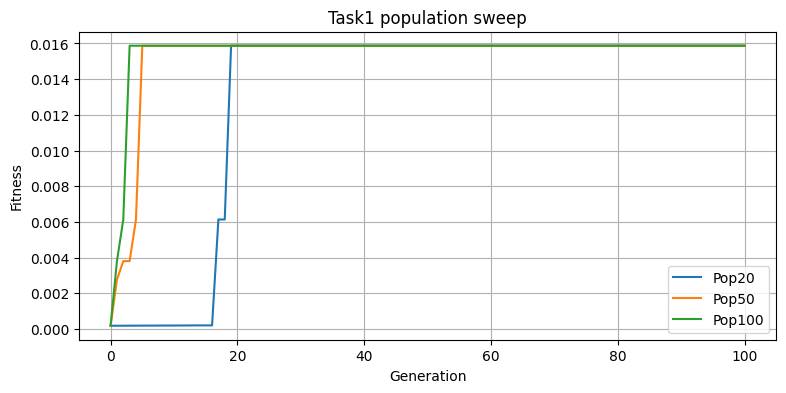

    label   fitness    time_s
0   Pop20  0.015873  0.041892
0   Pop50  0.015873  0.099945
0  Pop100  0.015873  0.229845


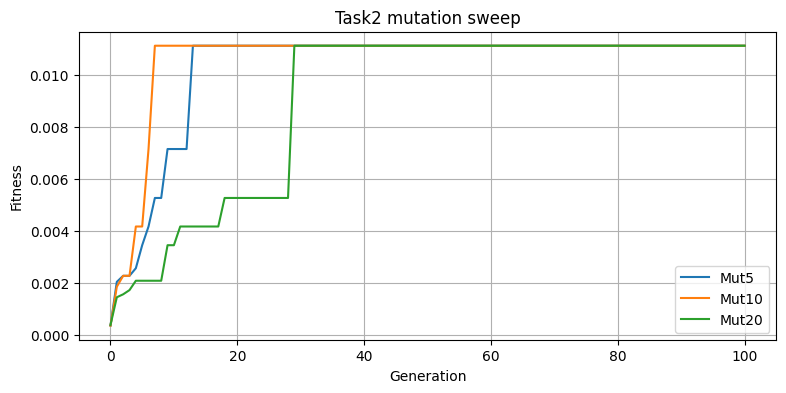

   label   fitness    time_s
0   Mut5  0.011111  0.179588
0  Mut10  0.011111  0.248243
0  Mut20  0.011111  0.379814


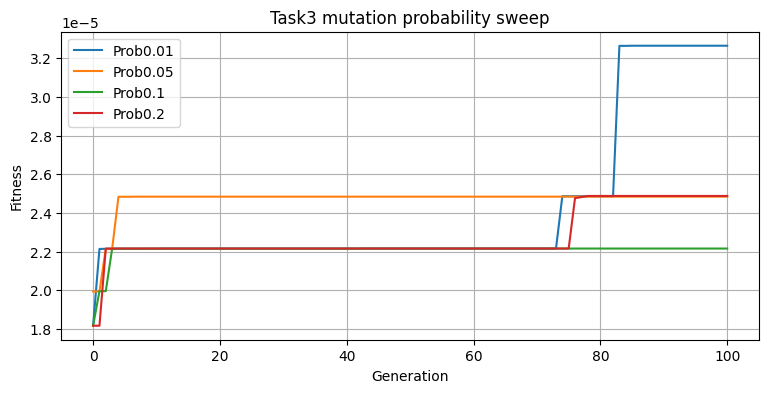

      label   fitness    time_s
0  Prob0.01  0.000033  1.732201
0  Prob0.05  0.000025  1.749342
0   Prob0.1  0.000022  1.811111
0   Prob0.2  0.000025  1.727139


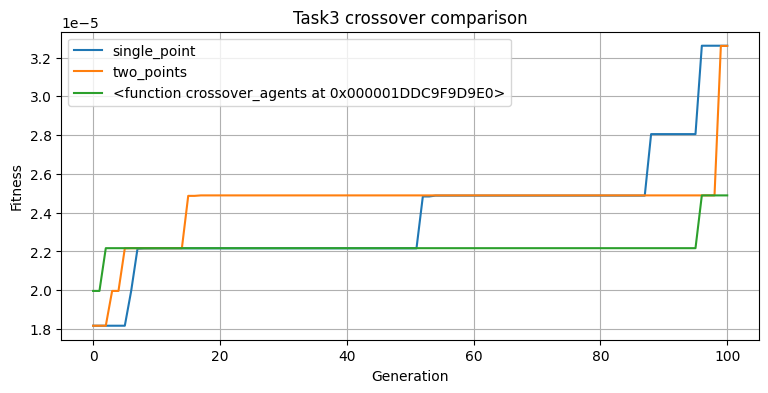

                                               label   fitness    time_s
0                                       single_point  0.000033  1.666960
0                                         two_points  0.000033  1.695402
0  <function crossover_agents at 0x000001DDC9F9D9E0>  0.000025  1.694361


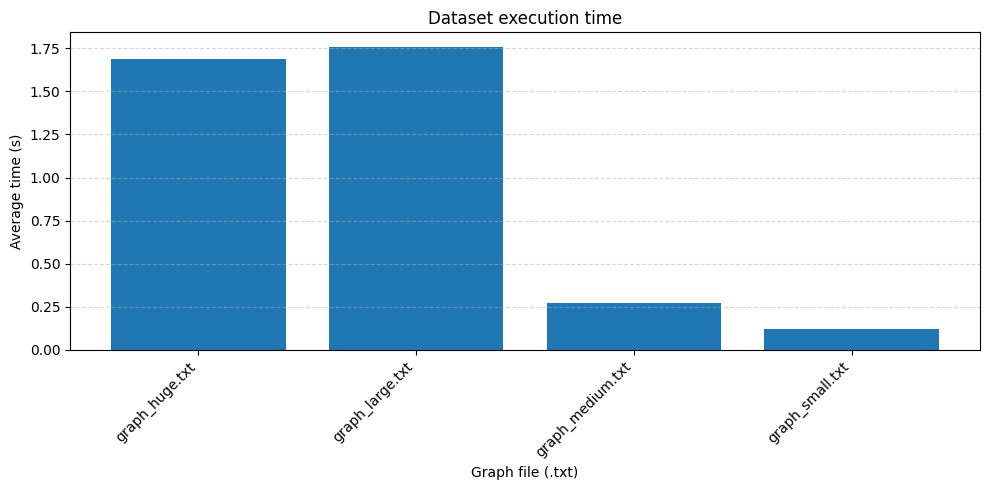

                                                label   fitness    time_s  \
0                                               Pop20  0.015873  0.041892   
1                                               Pop50  0.015873  0.099945   
2                                              Pop100  0.015873  0.229845   
3                                                Mut5  0.011111  0.179588   
4                                               Mut10  0.011111  0.248243   
5                                               Mut20  0.011111  0.379814   
6                                            Prob0.01  0.000033  1.732201   
7                                            Prob0.05  0.000025  1.749342   
8                                             Prob0.1  0.000022  1.811111   
9                                             Prob0.2  0.000025  1.727139   
10                                       single_point  0.000033  1.666960   
11                                         two_points  0.000033  1.695402   

In [5]:
# EXPERIMENTS ADAPTER (mutation/pop/crossover/compare)

import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygad

plt.rcParams['figure.figsize'] = (9,4)

# 1) Custom crossover for Task3 (agent-wise crossover)
def crossover_agents(parents, offspring_size, ga_instance):
    offspring = []
    for k in range(offspring_size[0]):
        p1 = parents[k % parents.shape[0]]
        p2 = parents[(k+1) % parents.shape[0]]
        cut = len(p1)//2
        child = np.concatenate((p1[:cut], p2[cut:])) if random.random()<0.5 else np.concatenate((p2[:cut], p1[cut:]))
        offspring.append(child)
    return np.array(offspring)

#  2) Run GA and record results
def run_ga(make_ga, label, repeats=1):
    rows, histories = [], []
    for r in range(repeats):
        ga = make_ga()
        t0 = time.time(); ga.run(); elapsed = time.time()-t0
        _, fit, _ = ga.best_solution()
        rows.append({'label':label, 'fitness':fit, 'time_s':elapsed})
        histories.append(ga.best_solutions_fitness)
    return pd.DataFrame(rows), histories

# 3) Plot helper 
def plot_histories(histories, labels, title):
    plt.figure()
    for h,l in zip(histories,labels):
        plt.plot(h, label=l)
    plt.legend(); plt.title(title)
    plt.xlabel("Generation"); plt.ylabel("Fitness"); plt.grid(); plt.show()

# ---------- 4) Example experiments ----------
# sweep population sizes for Task1
def sweep_population_task1(pop_sizes, gens=100):
    results = []
    histories = []
    labels = []
    for p in pop_sizes:
        df, hist = run_ga(lambda: pygad.GA(
            num_generations=gens, num_parents_mating=max(2, p//10), sol_per_pop=p,
            fitness_func=fitness_func, num_genes=num_nodes,
            gene_type=int, gene_space=list(range(1,num_nodes+1)),
            crossover_type="two_points", mutation_type="random",
            mutation_percent_genes=10), f"Pop{p}", repeats=1)
        results.append(df); histories.extend(hist); labels.append(f"Pop{p}")
    plot_histories(histories, labels, "Task1 population sweep")
    return pd.concat(results)

# sweep mutation rates for Task2
def sweep_mutation_task2(mutation_rates, pop=80, gens=100):
    results = []
    histories = []
    labels = []
    for m in mutation_rates:
        df, hist = run_ga(lambda: pygad.GA(
            num_generations=gens, num_parents_mating = max(2, pop//10), sol_per_pop=pop,
            fitness_func=fitness_multi_target, num_genes=TOTAL_GENES,
            gene_type=int, gene_space=list(range(1,num_nodes+1)),
            crossover_type="two_points", mutation_type="random",
            mutation_percent_genes=m), f"Mut{m}", repeats=1)
        results.append(df); histories.extend(hist); labels.append(f"Mut{m}")
    plot_histories(histories, labels, "Task2 mutation sweep")
    return pd.concat(results)

# sweep mutation sizes for Task3
def sweep_mutation_task3(mutation_probs, pop=80, gens=100):
    results = []
    histories = []
    labels = []
    for p in mutation_probs:
        df, hist = run_ga(lambda: pygad.GA(
            num_generations=gens, num_parents_mating=max(2, pop//10), sol_per_pop=pop,
            num_genes=NUM_GENES, gene_type=int, gene_space=list(range(1,num_nodes+1)),
            fitness_func=fitness_function_task3, crossover_type="single_point", 
            mutation_type=custom_mutation, mutation_probability=p
        ), f"Prob{p}", repeats=1)
        results.append(df); histories.extend(hist); labels.append(f"Prob{p}")
    plot_histories(histories, labels, "Task3 mutation probability sweep")
    return pd.concat(results)

# compare crossovers for Task3
def compare_crossovers_task3(crossovers, pop=80, gens=100):
    results = []
    histories = []
    labels = []
    for cross in crossovers:
        df, hist = run_ga(lambda: pygad.GA(
            num_generations=gens, num_parents_mating=max(2, pop//10), sol_per_pop=pop,
            fitness_func=fitness_function_task3, num_genes=NUM_GENES,
            gene_type=int, gene_space=list(range(1,num_nodes+1)),
            crossover_type=cross, mutation_type=custom_mutation), str(cross), repeats=1)
        results.append(df); histories.extend(hist); labels.append(str(cross))
    plot_histories(histories, labels, "Task3 crossover comparison")
    return pd.concat(results)

def compare_graphs(df):

    summary = df.groupby("graph_file")["time_s"].mean().reset_index()
    summary = summary.sort_values("graph_file")

    plt.figure(figsize=(10,5))
    plt.bar(summary["graph_file"], summary["time_s"])
    plt.xlabel("Graph file (.txt)")
    plt.ylabel("Average time (s)")
    plt.title("Dataset execution time")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Population sweep Task1
pop_sizes = [20, 50, 100]
df_pop = sweep_population_task1(pop_sizes, gens=100)
print(df_pop)

# Mutation sweep Task2
mutation_rates = [5, 10, 20]
df_mut = sweep_mutation_task2(mutation_rates, pop=80, gens=100)
print(df_mut)

# Mutation probabilty sweep Task3
mutation_probs = [0.01, 0.05, 0.1, 0.2]
df_mut3 = sweep_mutation_task3(mutation_probs, pop=80, gens=100)
print(df_mut3)

# Crossover comparison Task3
crossovers = ["single_point", "two_points", crossover_agents]
df_cross = compare_crossovers_task3(crossovers, pop=80, gens=100)
print(df_cross)

# Graph comparison
df_pop["graph_file"] = "graph_small.txt"
df_mut["graph_file"] = "graph_medium.txt"
df_mut3["graph_file"] = "graph_large.txt"
df_cross["graph_file"] = "graph_huge.txt"
all_df = pd.concat([df_pop, df_mut, df_mut3, df_cross], ignore_index=True)
compare_graphs(all_df)
print(all_df)

Task1 population sweep:
The graph shows that larger population (100) reaches optimal fitness in fewer generations than a small population (20).
That's because a small population suffers from a lack of genetic diversity, leading to premature convergence (That's why at first the blue line increases more than the orange one)
By increasing the population, we increase the capacity to explore the search space, covering more possible routes simultaneously.
However, the computational cost per generation increases when the population is bigger.

For medium-sized graphs (20 nodes), a population of 50 individuals proved to be the most efficient balance between execution time and solution quality.

Task2 mutation rate swap: a
Mutation rate = 5% (blue) is the slowest to imporve. The GA introduces very little variation each generation. Exploration is weak, late convergence. The algorithm tends to stagnate. It manages to reach the first objective but struggles to jump from that local optmum to find the second one. In conclusion, it provides too little exploration for the multi-segment pathfinding problem in Task 2.
Mutation rate = 10% (orange) is faster to improve than the 5% mutation rate. It stabilizes at a higher fitness plateau much earlier and provides faster convergence.
Mutation rate = 20% (green) is the fastest to imptove and reaches a higher fitness. It gives the best performance. In coclusion best exploration and solutions.
If we were to put a higher mutation (for example 50%) the algorithm would behave almost like a random walk, destroying the good path structures it would have found.

In conclusion, the mutation rate controles the balance between explotation and exploration. In sequential pathfinding problems, moderate mutation (20%) is crucial to introduce enough variability to allow the agent to unstick without destroying the valid path it has already built.

Task3 mutation prob sweep: it compares the best fitness across generations for four mutations probabilities.
Mutation = 0.01 (blue). Lowest variation. There is almost no mutation. There are too few path and the GA gets stuck. Slow and low-quality covergence. 
Mutation = 0.05 (orange). Much better exploration. A moderate mutation
Mutation = 0.1 (green) It shows the best fitness. The fitness curve rises steadily and reaches the highest peak, indicating that it has found a valid and efficient solution. In conclusion, it is the best solution, it has a good balance between innovation and stability.
Mutation = 0.2 (red) Although it has a strong early exploration, it becomes unstable or stagnates below the green line.

In conclusion, the results confirm that it requires a moderate-high mutational pressure (around 10%). Unlike simple oprimisarion problems, multi-agent coordination requires significant jumps in the search space to resolve deadlocks between agents.

Task3 crossover comparison: it shows the best fitness comparing three different types of crossovers.

The sigle-point (blue) is the worst performer since it is weak. It breaks segments, causing invalid movements and producing poor offspring.
Two-points (orange) is the best performer. Reaches the highest fitness fastest and it has a balance. Introduces variability in intermediate sections without ncessarily breaking the valid extremes.
Custom (green) Low diversity, very conservative. When moving such large blocks it truggles to fine-tune details.


Graph execution time comparison: it compares the average execution time across four different graph sizes.

Small graph: Times are very low (0.06–0.25s). Execution is extremely fast due to the small number of nodes and edges. Increasing the population size (Pop20 → Pop100) increases the time linearly. The GA converges quickly, but with minimal computational cost.

Medium graph: Times are higher (0.23–0.40s). The number of mutations (Mut5 → Mut20) clearly affects the execution time. The GA explores more paths, but the cost grows with mutation count. This indicates a trade-off between exploration and computational effort.

Large graph: Times jump sharply (~2s) and are largely independent of mutation probability (Prob0.01 → Prob0.2). The execution time is dominated by the graph size rather than algorithmic parameters. The GA still explores well, but efficiency is limited by graph processing.

Huge graph: Times remain around ~2s, similar to large graphs. Different crossover operators (single_point, two_points, crossover_agents) produce comparable execution times, showing that the choice of operator has minimal impact at this scale.

Conclusion: Execution time is primarily driven by graph size rather than GA parameters. Small graphs execute very fast; medium graphs scale linearly with mutations or population size; large and huge graphs saturate around 2s per run. Optimizing GA parameters alone will not significantly reduce time for large graphs improvements require more efficient graph handling or algorithmic optimizations.